In [63]:
## Import Libraries
import numpy as np 
import pandas as pd 
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from matplotlib import pyplot as plt
%matplotlib inline
import re
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

In [4]:
 ## load data
chess = pd.read_csv("Documents/magnus_carlsen_games.csv")

In [5]:
chess

,id,player_name,opponent_name,player_rating,opponent_rating,format,date,year,result,player_color,opponent_color,result_raw,moves
0,0,Magnus Carlsen,RainnWilson,2862,1200,Rapid,2014-12-14,2014,Win,white,black,1-0,1. e4 g6 2. Nf3 d6 3. d4 Bg7 4. Bc4 Bg4 5. Bxf...
1,1,Magnus Carlsen,solskytz,2862,1702,Rapid,2014-12-14,2014,Win,white,black,1-0,1. d4 Nf6 2. c4 e6 3. Nc3 Bb4 4. e3 c5 5. Ne2 ...
2,2,Magnus Carlsen,Tildenbeatsu,2862,1200,Rapid,2014-12-14,2014,Win,white,black,1-0,1. e4 e5 2. Nf3 Nc6 3. Bb5 Nf6 4. O-O Nxe4 5. ...
3,3,Magnus Carlsen,mtmnfy,2862,1200,Rapid,2014-12-14,2014,Win,white,black,1-0,1. d4 e6 2. e4 d5 3. Nd2 Nc6 4. Ngf3 Nf6 5. e5...
4,4,Magnus Carlsen,stepanosinovsky,2862,2360,Rapid,2014-12-14,2014,Loss,white,black,0-1,1. d4 Nf6 2. Bg5 c5 3. d5 Ne4 4. Bc1 e6 5. c4 ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6694,6694,Magnus Carlsen,BogdanDeac,2854,2724,Blitz,2026-01-02,2026,Win,white,black,1-0,1. c4 b6 2. Nbc3 g6 3. d3 Bg7 4. b4 c5 5. Bb2 ...
6695,6695,Magnus Carlsen,mishanick,2859,2689,Blitz,2026-01-02,2026,Win,black,white,1-0,1. b4 b5 2. Nb3 e6 3. e3 Bf6 4. Bxf6 gxf6 5. B...
6696,6696,Magnus Carlsen,jefferyx,2849,2781,Blitz,2026-01-02,2026,Loss,white,black,0-1,1. d4 g6 2. b3 f5 3. g3 Nf7 4. Nd3 Bg7 5. c4 O...
6697,6697,Magnus Carlsen,DonkyDonkyDonkey,2853,2645,Blitz,2026-01-02,2026,Win,black,white,1-0,1. f4 g6 2. g3 f5 3. Nc3 Bxc3 4. bxc3 d6 5. Nb...


In [7]:
def get_opening_moves(move_string):
    if pd.isna(move_string):
        return "Unknown"
    match = re.search(r'^(.*?)\s3\.', move_string)
    if match:
        return match.group(1).strip()
    return move_string 
chess['opening_sequence'] = chess['moves'].apply(get_opening_moves)

In [8]:
chess

,id,player_name,opponent_name,player_rating,opponent_rating,format,date,year,result,player_color,opponent_color,result_raw,moves,opening_sequence
0,0,Magnus Carlsen,RainnWilson,2862,1200,Rapid,2014-12-14,2014,Win,white,black,1-0,1. e4 g6 2. Nf3 d6 3. d4 Bg7 4. Bc4 Bg4 5. Bxf...,1. e4 g6 2. Nf3 d6
1,1,Magnus Carlsen,solskytz,2862,1702,Rapid,2014-12-14,2014,Win,white,black,1-0,1. d4 Nf6 2. c4 e6 3. Nc3 Bb4 4. e3 c5 5. Ne2 ...,1. d4 Nf6 2. c4 e6
2,2,Magnus Carlsen,Tildenbeatsu,2862,1200,Rapid,2014-12-14,2014,Win,white,black,1-0,1. e4 e5 2. Nf3 Nc6 3. Bb5 Nf6 4. O-O Nxe4 5. ...,1. e4 e5 2. Nf3 Nc6
3,3,Magnus Carlsen,mtmnfy,2862,1200,Rapid,2014-12-14,2014,Win,white,black,1-0,1. d4 e6 2. e4 d5 3. Nd2 Nc6 4. Ngf3 Nf6 5. e5...,1. d4 e6 2. e4 d5
4,4,Magnus Carlsen,stepanosinovsky,2862,2360,Rapid,2014-12-14,2014,Loss,white,black,0-1,1. d4 Nf6 2. Bg5 c5 3. d5 Ne4 4. Bc1 e6 5. c4 ...,1. d4 Nf6 2. Bg5 c5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6694,6694,Magnus Carlsen,BogdanDeac,2854,2724,Blitz,2026-01-02,2026,Win,white,black,1-0,1. c4 b6 2. Nbc3 g6 3. d3 Bg7 4. b4 c5 5. Bb2 ...,1. c4 b6 2. Nbc3 g6
6695,6695,Magnus Carlsen,mishanick,2859,2689,Blitz,2026-01-02,2026,Win,black,white,1-0,1. b4 b5 2. Nb3 e6 3. e3 Bf6 4. Bxf6 gxf6 5. B...,1. b4 b5 2. Nb3 e6
6696,6696,Magnus Carlsen,jefferyx,2849,2781,Blitz,2026-01-02,2026,Loss,white,black,0-1,1. d4 g6 2. b3 f5 3. g3 Nf7 4. Nd3 Bg7 5. c4 O...,1. d4 g6 2. b3 f5
6697,6697,Magnus Carlsen,DonkyDonkyDonkey,2853,2645,Blitz,2026-01-02,2026,Win,black,white,1-0,1. f4 g6 2. g3 f5 3. Nc3 Bxc3 4. bxc3 d6 5. Nb...,1. f4 g6 2. g3 f5


In [9]:
chess

,id,player_name,opponent_name,player_rating,opponent_rating,format,date,year,result,player_color,opponent_color,result_raw,moves,opening_sequence
0,0,Magnus Carlsen,RainnWilson,2862,1200,Rapid,2014-12-14,2014,Win,white,black,1-0,1. e4 g6 2. Nf3 d6 3. d4 Bg7 4. Bc4 Bg4 5. Bxf...,1. e4 g6 2. Nf3 d6
1,1,Magnus Carlsen,solskytz,2862,1702,Rapid,2014-12-14,2014,Win,white,black,1-0,1. d4 Nf6 2. c4 e6 3. Nc3 Bb4 4. e3 c5 5. Ne2 ...,1. d4 Nf6 2. c4 e6
2,2,Magnus Carlsen,Tildenbeatsu,2862,1200,Rapid,2014-12-14,2014,Win,white,black,1-0,1. e4 e5 2. Nf3 Nc6 3. Bb5 Nf6 4. O-O Nxe4 5. ...,1. e4 e5 2. Nf3 Nc6
3,3,Magnus Carlsen,mtmnfy,2862,1200,Rapid,2014-12-14,2014,Win,white,black,1-0,1. d4 e6 2. e4 d5 3. Nd2 Nc6 4. Ngf3 Nf6 5. e5...,1. d4 e6 2. e4 d5
4,4,Magnus Carlsen,stepanosinovsky,2862,2360,Rapid,2014-12-14,2014,Loss,white,black,0-1,1. d4 Nf6 2. Bg5 c5 3. d5 Ne4 4. Bc1 e6 5. c4 ...,1. d4 Nf6 2. Bg5 c5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6694,6694,Magnus Carlsen,BogdanDeac,2854,2724,Blitz,2026-01-02,2026,Win,white,black,1-0,1. c4 b6 2. Nbc3 g6 3. d3 Bg7 4. b4 c5 5. Bb2 ...,1. c4 b6 2. Nbc3 g6
6695,6695,Magnus Carlsen,mishanick,2859,2689,Blitz,2026-01-02,2026,Win,black,white,1-0,1. b4 b5 2. Nb3 e6 3. e3 Bf6 4. Bxf6 gxf6 5. B...,1. b4 b5 2. Nb3 e6
6696,6696,Magnus Carlsen,jefferyx,2849,2781,Blitz,2026-01-02,2026,Loss,white,black,0-1,1. d4 g6 2. b3 f5 3. g3 Nf7 4. Nd3 Bg7 5. c4 O...,1. d4 g6 2. b3 f5
6697,6697,Magnus Carlsen,DonkyDonkyDonkey,2853,2645,Blitz,2026-01-02,2026,Win,black,white,1-0,1. f4 g6 2. g3 f5 3. Nc3 Bxc3 4. bxc3 d6 5. Nb...,1. f4 g6 2. g3 f5


In [10]:
## encode
le = LabelEncoder()
chess['moves_encoded'] = le.fit_transform(chess['opening_sequence'])

In [11]:
## Count Player
chess['opponent_name'].nunique()

945

In [12]:
opponent_v = chess.opponent_name.value_counts()
opponent_v

opponent_name
DanielNaroditsky    412
NikoTheodorou       344
Njal28              212
mishanick           170
Hikaru              157
                   ... 
MikaKarttunen         1
superchess02          1
AccioChess            1
annasargsyan_m        1
honestgames           1
Name: count, Length: 945, dtype: int64

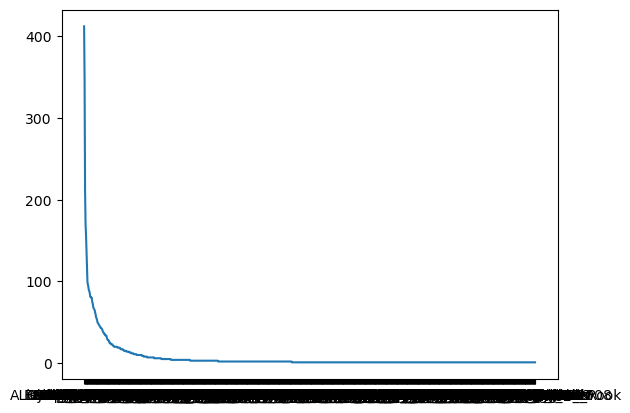

In [13]:
plt.plot(opponent_v)
plt.show()

In [14]:
## encode
le = LabelEncoder()
chess['opponent_encoded'] = le.fit_transform(chess['opponent_name'])

In [15]:
chess

,id,player_name,opponent_name,player_rating,opponent_rating,format,date,year,result,player_color,opponent_color,result_raw,moves,opening_sequence,moves_encoded,opponent_encoded
0,0,Magnus Carlsen,RainnWilson,2862,1200,Rapid,2014-12-14,2014,Win,white,black,1-0,1. e4 g6 2. Nf3 d6 3. d4 Bg7 4. Bc4 Bg4 5. Bxf...,1. e4 g6 2. Nf3 d6,869,482
1,1,Magnus Carlsen,solskytz,2862,1702,Rapid,2014-12-14,2014,Win,white,black,1-0,1. d4 Nf6 2. c4 e6 3. Nc3 Bb4 4. e3 c5 5. Ne2 ...,1. d4 Nf6 2. c4 e6,456,880
2,2,Magnus Carlsen,Tildenbeatsu,2862,1200,Rapid,2014-12-14,2014,Win,white,black,1-0,1. e4 e5 2. Nf3 Nc6 3. Bb5 Nf6 4. O-O Nxe4 5. ...,1. e4 e5 2. Nf3 Nc6,804,585
3,3,Magnus Carlsen,mtmnfy,2862,1200,Rapid,2014-12-14,2014,Win,white,black,1-0,1. d4 e6 2. e4 d5 3. Nd2 Nc6 4. Ngf3 Nf6 5. e5...,1. d4 e6 2. e4 d5,584,822
4,4,Magnus Carlsen,stepanosinovsky,2862,2360,Rapid,2014-12-14,2014,Loss,white,black,0-1,1. d4 Nf6 2. Bg5 c5 3. d5 Ne4 4. Bc1 e6 5. c4 ...,1. d4 Nf6 2. Bg5 c5,429,885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6694,6694,Magnus Carlsen,BogdanDeac,2854,2724,Blitz,2026-01-02,2026,Win,white,black,1-0,1. c4 b6 2. Nbc3 g6 3. d3 Bg7 4. b4 c5 5. Bb2 ...,1. c4 b6 2. Nbc3 g6,310,87
6695,6695,Magnus Carlsen,mishanick,2859,2689,Blitz,2026-01-02,2026,Win,black,white,1-0,1. b4 b5 2. Nb3 e6 3. e3 Bf6 4. Bxf6 gxf6 5. B...,1. b4 b5 2. Nb3 e6,251,814
6696,6696,Magnus Carlsen,jefferyx,2849,2781,Blitz,2026-01-02,2026,Loss,white,black,0-1,1. d4 g6 2. b3 f5 3. g3 Nf7 4. Nd3 Bg7 5. c4 O...,1. d4 g6 2. b3 f5,610,773
6697,6697,Magnus Carlsen,DonkyDonkyDonkey,2853,2645,Blitz,2026-01-02,2026,Win,black,white,1-0,1. f4 g6 2. g3 f5 3. Nc3 Bxc3 4. bxc3 d6 5. Nb...,1. f4 g6 2. g3 f5,929,150


In [16]:
res = chess.result.value_counts()
res

result
Win     4756
Loss    1326
Draw     617
Name: count, dtype: int64

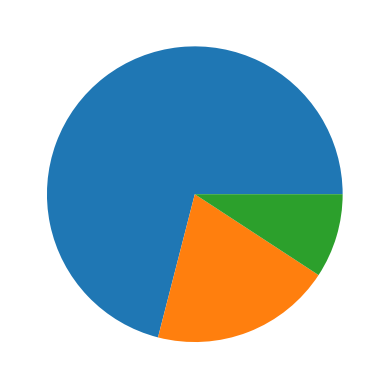

In [17]:
plt.pie(res)
plt.show()

In [18]:
## drop column name
chess = chess.drop("player_name", axis = 1 )
chess = chess.drop("opponent_name", axis = 1 )

In [19]:
chess

,id,player_rating,opponent_rating,format,date,year,result,player_color,opponent_color,result_raw,moves,opening_sequence,moves_encoded,opponent_encoded
0,0,2862,1200,Rapid,2014-12-14,2014,Win,white,black,1-0,1. e4 g6 2. Nf3 d6 3. d4 Bg7 4. Bc4 Bg4 5. Bxf...,1. e4 g6 2. Nf3 d6,869,482
1,1,2862,1702,Rapid,2014-12-14,2014,Win,white,black,1-0,1. d4 Nf6 2. c4 e6 3. Nc3 Bb4 4. e3 c5 5. Ne2 ...,1. d4 Nf6 2. c4 e6,456,880
2,2,2862,1200,Rapid,2014-12-14,2014,Win,white,black,1-0,1. e4 e5 2. Nf3 Nc6 3. Bb5 Nf6 4. O-O Nxe4 5. ...,1. e4 e5 2. Nf3 Nc6,804,585
3,3,2862,1200,Rapid,2014-12-14,2014,Win,white,black,1-0,1. d4 e6 2. e4 d5 3. Nd2 Nc6 4. Ngf3 Nf6 5. e5...,1. d4 e6 2. e4 d5,584,822
4,4,2862,2360,Rapid,2014-12-14,2014,Loss,white,black,0-1,1. d4 Nf6 2. Bg5 c5 3. d5 Ne4 4. Bc1 e6 5. c4 ...,1. d4 Nf6 2. Bg5 c5,429,885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6694,6694,2854,2724,Blitz,2026-01-02,2026,Win,white,black,1-0,1. c4 b6 2. Nbc3 g6 3. d3 Bg7 4. b4 c5 5. Bb2 ...,1. c4 b6 2. Nbc3 g6,310,87
6695,6695,2859,2689,Blitz,2026-01-02,2026,Win,black,white,1-0,1. b4 b5 2. Nb3 e6 3. e3 Bf6 4. Bxf6 gxf6 5. B...,1. b4 b5 2. Nb3 e6,251,814
6696,6696,2849,2781,Blitz,2026-01-02,2026,Loss,white,black,0-1,1. d4 g6 2. b3 f5 3. g3 Nf7 4. Nd3 Bg7 5. c4 O...,1. d4 g6 2. b3 f5,610,773
6697,6697,2853,2645,Blitz,2026-01-02,2026,Win,black,white,1-0,1. f4 g6 2. g3 f5 3. Nc3 Bxc3 4. bxc3 d6 5. Nb...,1. f4 g6 2. g3 f5,929,150


In [21]:
## Count_moves_in_match
def count_moves(moves):
    if pd.isna(moves): return 0
    moves = str(moves)
    clean = re.sub(r'\d+\.', '', moves)
    return len(clean.split())
chess['num_moves'] = chess['moves'].apply(count_moves)

In [22]:
## drop col moves
chess = chess.drop("moves", axis = 1 )

In [23]:
chess

,id,player_rating,opponent_rating,format,date,year,result,player_color,opponent_color,result_raw,opening_sequence,moves_encoded,opponent_encoded,num_moves
0,0,2862,1200,Rapid,2014-12-14,2014,Win,white,black,1-0,1. e4 g6 2. Nf3 d6,869,482,55
1,1,2862,1702,Rapid,2014-12-14,2014,Win,white,black,1-0,1. d4 Nf6 2. c4 e6,456,880,57
2,2,2862,1200,Rapid,2014-12-14,2014,Win,white,black,1-0,1. e4 e5 2. Nf3 Nc6,804,585,53
3,3,2862,1200,Rapid,2014-12-14,2014,Win,white,black,1-0,1. d4 e6 2. e4 d5,584,822,69
4,4,2862,2360,Rapid,2014-12-14,2014,Loss,white,black,0-1,1. d4 Nf6 2. Bg5 c5,429,885,82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6694,6694,2854,2724,Blitz,2026-01-02,2026,Win,white,black,1-0,1. c4 b6 2. Nbc3 g6,310,87,35
6695,6695,2859,2689,Blitz,2026-01-02,2026,Win,black,white,1-0,1. b4 b5 2. Nb3 e6,251,814,102
6696,6696,2849,2781,Blitz,2026-01-02,2026,Loss,white,black,0-1,1. d4 g6 2. b3 f5,610,773,60
6697,6697,2853,2645,Blitz,2026-01-02,2026,Win,black,white,1-0,1. f4 g6 2. g3 f5,929,150,82


In [24]:
## Rapid = 0   Biltz = 1
a=pd.get_dummies(chess.format).astype(int) 
a=a.drop("Rapid", axis=1)
chess = pd.concat([a,chess],axis=1)
chess.rename(columns = {"Blitz":"Format"},inplace = True) 

In [25]:
chess

,Format,id,player_rating,opponent_rating,format,date,year,result,player_color,opponent_color,result_raw,opening_sequence,moves_encoded,opponent_encoded,num_moves
0,0,0,2862,1200,Rapid,2014-12-14,2014,Win,white,black,1-0,1. e4 g6 2. Nf3 d6,869,482,55
1,0,1,2862,1702,Rapid,2014-12-14,2014,Win,white,black,1-0,1. d4 Nf6 2. c4 e6,456,880,57
2,0,2,2862,1200,Rapid,2014-12-14,2014,Win,white,black,1-0,1. e4 e5 2. Nf3 Nc6,804,585,53
3,0,3,2862,1200,Rapid,2014-12-14,2014,Win,white,black,1-0,1. d4 e6 2. e4 d5,584,822,69
4,0,4,2862,2360,Rapid,2014-12-14,2014,Loss,white,black,0-1,1. d4 Nf6 2. Bg5 c5,429,885,82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6694,1,6694,2854,2724,Blitz,2026-01-02,2026,Win,white,black,1-0,1. c4 b6 2. Nbc3 g6,310,87,35
6695,1,6695,2859,2689,Blitz,2026-01-02,2026,Win,black,white,1-0,1. b4 b5 2. Nb3 e6,251,814,102
6696,1,6696,2849,2781,Blitz,2026-01-02,2026,Loss,white,black,0-1,1. d4 g6 2. b3 f5,610,773,60
6697,1,6697,2853,2645,Blitz,2026-01-02,2026,Win,black,white,1-0,1. f4 g6 2. g3 f5,929,150,82


In [26]:
## drop unuseful col
chess = chess.drop("id", axis = 1 )
chess = chess.drop("format", axis = 1 )

In [27]:
chess

,Format,player_rating,opponent_rating,date,year,result,player_color,opponent_color,result_raw,opening_sequence,moves_encoded,opponent_encoded,num_moves
0,0,2862,1200,2014-12-14,2014,Win,white,black,1-0,1. e4 g6 2. Nf3 d6,869,482,55
1,0,2862,1702,2014-12-14,2014,Win,white,black,1-0,1. d4 Nf6 2. c4 e6,456,880,57
2,0,2862,1200,2014-12-14,2014,Win,white,black,1-0,1. e4 e5 2. Nf3 Nc6,804,585,53
3,0,2862,1200,2014-12-14,2014,Win,white,black,1-0,1. d4 e6 2. e4 d5,584,822,69
4,0,2862,2360,2014-12-14,2014,Loss,white,black,0-1,1. d4 Nf6 2. Bg5 c5,429,885,82
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6694,1,2854,2724,2026-01-02,2026,Win,white,black,1-0,1. c4 b6 2. Nbc3 g6,310,87,35
6695,1,2859,2689,2026-01-02,2026,Win,black,white,1-0,1. b4 b5 2. Nb3 e6,251,814,102
6696,1,2849,2781,2026-01-02,2026,Loss,white,black,0-1,1. d4 g6 2. b3 f5,610,773,60
6697,1,2853,2645,2026-01-02,2026,Win,black,white,1-0,1. f4 g6 2. g3 f5,929,150,82


In [28]:
a=pd.get_dummies(chess.player_color).astype(int) 
a=a.drop("black", axis=1)
chess = pd.concat([a,chess],axis=1)
chess.rename(columns = {"white":"Player_color"},inplace = True) 

In [29]:
chess

,Player_color,Format,player_rating,opponent_rating,date,year,result,player_color,opponent_color,result_raw,opening_sequence,moves_encoded,opponent_encoded,num_moves
0,1,0,2862,1200,2014-12-14,2014,Win,white,black,1-0,1. e4 g6 2. Nf3 d6,869,482,55
1,1,0,2862,1702,2014-12-14,2014,Win,white,black,1-0,1. d4 Nf6 2. c4 e6,456,880,57
2,1,0,2862,1200,2014-12-14,2014,Win,white,black,1-0,1. e4 e5 2. Nf3 Nc6,804,585,53
3,1,0,2862,1200,2014-12-14,2014,Win,white,black,1-0,1. d4 e6 2. e4 d5,584,822,69
4,1,0,2862,2360,2014-12-14,2014,Loss,white,black,0-1,1. d4 Nf6 2. Bg5 c5,429,885,82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6694,1,1,2854,2724,2026-01-02,2026,Win,white,black,1-0,1. c4 b6 2. Nbc3 g6,310,87,35
6695,0,1,2859,2689,2026-01-02,2026,Win,black,white,1-0,1. b4 b5 2. Nb3 e6,251,814,102
6696,1,1,2849,2781,2026-01-02,2026,Loss,white,black,0-1,1. d4 g6 2. b3 f5,610,773,60
6697,0,1,2853,2645,2026-01-02,2026,Win,black,white,1-0,1. f4 g6 2. g3 f5,929,150,82


In [30]:
## encode
le = LabelEncoder()
chess['result_encoded'] = le.fit_transform(chess['result_raw'])

In [31]:
## Drop_col_unuseful
chess = chess.drop(["date","player_color","opponent_color","result"],axis=1)

In [32]:
chess=chess.drop("result_raw", axis=1)

In [33]:
## (win = 2   draw = 1 loss = 0)       (Rapid = 0   Biltz = 1)  (white = 1 black = 0)
chess

,Player_color,Format,player_rating,opponent_rating,year,opening_sequence,moves_encoded,opponent_encoded,num_moves,result_encoded
0,1,0,2862,1200,2014,1. e4 g6 2. Nf3 d6,869,482,55,2
1,1,0,2862,1702,2014,1. d4 Nf6 2. c4 e6,456,880,57,2
2,1,0,2862,1200,2014,1. e4 e5 2. Nf3 Nc6,804,585,53,2
3,1,0,2862,1200,2014,1. d4 e6 2. e4 d5,584,822,69,2
4,1,0,2862,2360,2014,1. d4 Nf6 2. Bg5 c5,429,885,82,0
...,...,...,...,...,...,...,...,...,...,...
6694,1,1,2854,2724,2026,1. c4 b6 2. Nbc3 g6,310,87,35,2
6695,0,1,2859,2689,2026,1. b4 b5 2. Nb3 e6,251,814,102,2
6696,1,1,2849,2781,2026,1. d4 g6 2. b3 f5,610,773,60,0
6697,0,1,2853,2645,2026,1. f4 g6 2. g3 f5,929,150,82,2


In [34]:
chess.result_encoded.value_counts()

result_encoded
2    4756
0    1326
1     617
Name: count, dtype: int64

In [48]:
x = chess.drop(["result_encoded","opening_sequence"],axis=1)
y = chess[["result_encoded"]]

In [49]:
y

,result_encoded
0,2
1,2
2,2
3,2
4,0
...,...
6694,2
6695,2
6696,0
6697,2


In [50]:
x

,Player_color,Format,player_rating,opponent_rating,year,moves_encoded,opponent_encoded,num_moves
0,1,0,2862,1200,2014,869,482,55
1,1,0,2862,1702,2014,456,880,57
2,1,0,2862,1200,2014,804,585,53
3,1,0,2862,1200,2014,584,822,69
4,1,0,2862,2360,2014,429,885,82
...,...,...,...,...,...,...,...,...
6694,1,1,2854,2724,2026,310,87,35
6695,0,1,2859,2689,2026,251,814,102
6696,1,1,2849,2781,2026,610,773,60
6697,0,1,2853,2645,2026,929,150,82


In [51]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,train_size=0.8,stratify=y)

In [52]:
xtrain

,Player_color,Format,player_rating,opponent_rating,year,moves_encoded,opponent_encoded,num_moves
583,0,1,3240,3159,2022,804,137,127
2794,1,1,3327,3071,2023,547,930,145
481,0,1,3221,2986,2022,673,775,86
2574,0,1,3277,3087,2023,684,723,135
2543,1,1,3292,3096,2023,715,814,45
...,...,...,...,...,...,...,...,...
4488,0,1,3313,3083,2024,873,662,42
3821,1,1,3307,2553,2024,554,78,65
4126,1,1,3246,3192,2024,715,193,78
2166,1,1,3270,3033,2023,423,143,87


In [53]:
xtest

,Player_color,Format,player_rating,opponent_rating,year,moves_encoded,opponent_encoded,num_moves
4711,1,1,3310,3011,2024,117,848,97
1503,0,1,3182,2733,2023,703,192,84
2266,0,1,3235,2988,2023,522,590,157
789,1,1,3248,3019,2022,870,446,123
6367,0,1,3320,2939,2025,311,803,94
...,...,...,...,...,...,...,...,...
2631,0,1,3242,3055,2023,681,444,115
1830,0,1,3218,3102,2023,371,182,153
2470,0,1,3217,3014,2023,761,444,70
5398,1,1,2793,2491,2025,1018,930,130


In [54]:
model = RandomForestClassifier(n_estimators=100)

In [55]:
model.fit(xtrain,ytrain)

RandomForestClassifier()

In [56]:
##pprediction xtest
prediction  = model.predict(xtest)
prediction

array([2, 2, 2, ..., 2, 2, 2])

In [57]:
len(ytrain)

5359

In [58]:
## score train
train = model.score(xtrain,ytrain)
train

1.0

In [59]:
## score test
test = model.score(xtest,ytest)
test

0.7156716417910448

In [60]:
## Train accuracy (0.99) and test accuracy (0.71)
train_accuracy = train - test
train_accuracy

0.2843283582089552

In [61]:
train_acc = []
test_acc  = []
for i in range(3,100) :
    model = RandomForestClassifier(n_estimators=i)
    model.fit(xtrain , ytrain)
    train_acc.append(model.score(xtrain , ytrain))
    test_acc.append(model.score(xtest,ytest))

In [62]:
train_acc

[0.9261056167195372,
 0.9477514461653294,
 0.9582011569322635,
 0.9725695092367979,
 0.9740623250606456,
 0.9813398022019033,
 0.9841388318716179,
 0.9865646575853704,
 0.9843254338495988,
 0.9925359208807614,
 0.9916029109908565,
 0.9930957268147043,
 0.9919761149468185,
 0.9947751446165329,
 0.99421533868259,
 0.9953349505504758,
 0.9960813584623996,
 0.9960813584623996,
 0.9964545624183616,
 0.9972009703302855,
 0.9970143683523045,
 0.9981339802201903,
 0.9972009703302855,
 0.9985071841761523,
 0.9977607762642284,
 0.9977607762642284,
 0.9986937861541332,
 0.9979473782422094,
 0.9983205821981713,
 0.9981339802201903,
 0.9983205821981713,
 0.9992535920880762,
 0.9981339802201903,
 0.9988803881321142,
 0.9988803881321142,
 0.9992535920880762,
 0.9990669901100951,
 0.9992535920880762,
 0.9986937861541332,
 0.9994401940660571,
 0.9992535920880762,
 0.9998133980220191,
 1.0,
 0.9998133980220191,
 0.9998133980220191,
 0.9994401940660571,
 0.9992535920880762,
 0.9992535920880762,
 0.999813

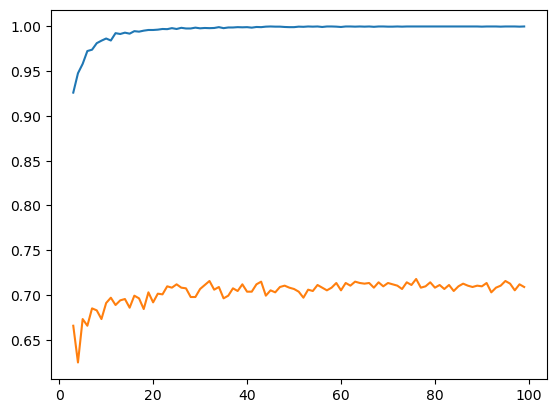

In [64]:
plt.plot( range(3,100),train_acc)
plt.plot( range(3,100),test_acc)
plt.show()